<a href="https://colab.research.google.com/github/2303A510G4-star/HPC-Project/blob/main/HPC_Project_10G4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parallel Prime Number Generator using Multithreading (CPU vs GPU Performance Analysis)

#              USE CASE SCENARIO


       Scenario  :   Large-Scale Scientific Number Analysis

In a research laboratory, scientists need to analyze very large ranges of numbers to identify prime numbers.

Prime numbers are important in:

Cryptography systems
Secure banking transactions
Password encryption
Scientific simulations

The researchers generate:

 A large range of numbers (1 – 500,000 or more)

All these numbers are stored in a file Numbers.txt

**Problem**

Find all prime numbers within the given range efficiently.

We check each number using three computational methods:

Serial CPU Execution
Numbers are checked one by one → slow execution.
Parallel CPU Execution (Multithreading / OpenMP)
Multiple CPU cores check many numbers simultaneously → faster.
GPU Execution (CUDA)
Thousands of GPU threads test numbers at the same time → fastest approach.

Since modern applications process millions of numbers, fast computation becomes essential.

**Why This Is Important .**

Large datasets contain lakhs or millions of numbers
Prime generation is heavily used in encryption systems
Faster computation improves real-time security systems
Parallel computing significantly reduces execution time

In [ ]:
%%writefile generate_numbers.py
limit = 100000

with open("Numbers.txt", "w") as f:
    for i in range(1, limit + 1):
        f.write(str(i) + "\n")

print("Numbers.txt created")

Writing generate_numbers.py


In [ ]:
!python generate_numbers.py

Numbers.txt created


In [ ]:
!ls

generate_numbers.py  gpu_output.txt  gpu_prime.py  Numbers.txt	sample_data


# CPU CODE (Serial vs Parallel)

In [ ]:
%%writefile cpu_prime_threads.c
#include <stdio.h>
#include <math.h>
#include <time.h>
#include <pthread.h>

#define MAX 200000
#define THREADS 4

int numbers[MAX];
int n = 0;
int count_parallel = 0;

typedef struct {
    int start;
    int end;
} ThreadData;

int isPrime(int num) {
    if (num < 2) return 0;
    for (int i = 2; i <= sqrt(num); i++) {
        if (num % i == 0)
            return 0;
    }
    return 1;
}

void* findPrimes(void* arg) {
    ThreadData* data = (ThreadData*)arg;
    int local_count = 0;

    for (int i = data->start; i < data->end; i++) {
        if (isPrime(numbers[i]))
            local_count++;
    }

    __sync_fetch_and_add(&count_parallel, local_count);
    return NULL;
}

int main() {
    FILE *fp = fopen("Numbers.txt", "r");

    if (fp == NULL) {
        printf("Error opening Numbers.txt\n");
        return 1;
    }

    while (fscanf(fp, "%d", &numbers[n]) != EOF) n++;
    fclose(fp);

    printf("Total Numbers: %d\n", n);

    int repeat;
    printf("Enter repeat count: ");
    scanf("%d", &repeat);

    int count_serial = 0;

    // SERIAL
    clock_t s1 = clock();
    for (int r = 0; r < repeat; r++) {
        count_serial = 0;
        for (int i = 0; i < n; i++) {
            if (isPrime(numbers[i]))
                count_serial++;
        }
    }
    clock_t e1 = clock();

    double serial = (double)(e1 - s1) / CLOCKS_PER_SEC;

    // PARALLEL (THREADS)
    double s2 = (double)clock() / CLOCKS_PER_SEC;

    for (int r = 0; r < repeat; r++) {
        pthread_t threads[THREADS];
        ThreadData data[THREADS];
        count_parallel = 0;

        int chunk = n / THREADS;

        for (int i = 0; i < THREADS; i++) {
            data[i].start = i * chunk;
            data[i].end = (i == THREADS - 1) ? n : (i + 1) * chunk;

            pthread_create(&threads[i], NULL, findPrimes, &data[i]);
        }

        for (int i = 0; i < THREADS; i++) {
            pthread_join(threads[i], NULL);
        }
    }

    double e2 = (double)clock() / CLOCKS_PER_SEC;

    double parallel = e2 - s2;

    printf("Serial Time = %f sec\n", serial);
    printf("Parallel Time = %f sec\n", parallel);

    FILE *out = fopen("cpu_output.txt", "w");
    fprintf(out, "%f %f", serial, parallel);
    fclose(out);

    return 0;
}

Writing cpu_prime_threads.c


In [ ]:
!gcc cpu_prime_threads.c -o cpu_prime_threads -lm -lpthread
!./cpu_prime_threads

Total Numbers: 100000
Enter repeat count: 5
Serial Time = 0.063661 sec
Parallel Time = 0.107454 sec


In [ ]:
!ls

cpu_output.txt	   cpu_prime_threads.c	gpu_output.txt	Numbers.txt
cpu_prime_threads  generate_numbers.py	gpu_prime.py	sample_data



# GPU CODE (CUDA)

In [ ]:
%%writefile gpu_prime.py
from numba import cuda
import numpy as np
import math
import time

@cuda.jit
def is_prime_gpu(nums, results):
    idx = cuda.grid(1)
    if idx < nums.size:
        n = nums[idx]
        if n < 2:
            results[idx] = 0
            return
        flag = 1
        for i in range(2, int(math.sqrt(n)) + 1):
            if n % i == 0:
                flag = 0
                break
        results[idx] = flag

nums = np.arange(1, 100000)
results = np.zeros_like(nums)

d_nums = cuda.to_device(nums)
d_results = cuda.to_device(results)

threads = 256
blocks = (nums.size + threads - 1) // threads

start = time.time()

is_prime_gpu[blocks, threads](d_nums, d_results)
cuda.synchronize()

end = time.time()

results = d_results.copy_to_host()
count = np.sum(results)

print("Total Primes:", count)
print("GPU Time:", (end - start), "sec")

with open("gpu_output.txt", "w") as f:
    f.write(str((end - start) * 1000))

Overwriting gpu_prime.py


In [ ]:
!python gpu_prime.py

Total Primes: 9592
GPU Time: 0.4583868980407715 sec


In [ ]:
!ls

cpu_output.txt	   cpu_prime_threads.c	gpu_output.txt	Numbers.txt
cpu_prime_threads  generate_numbers.py	gpu_prime.py	sample_data


# PYTHON CODE (Visualization + Details)


FINAL RESULT
Serial   : 0.063661 sec
Parallel : 0.107454 sec
GPU      : 0.4583868980407715 sec


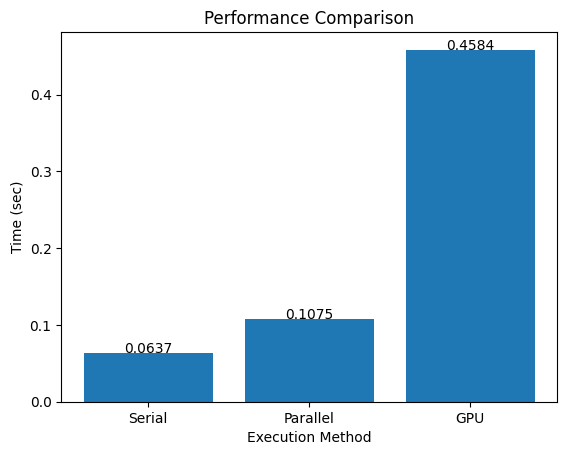

In [ ]:
import matplotlib.pyplot as plt

with open("cpu_output.txt") as f:
    serial, parallel = map(float, f.read().split())

with open("gpu_output.txt") as f:
    gpu = float(f.read()) / 1000

print("\nFINAL RESULT")
print("Serial   :", serial, "sec")
print("Parallel :", parallel, "sec")
print("GPU      :", gpu, "sec")

methods = ['Serial', 'Parallel', 'GPU']
times = [serial, parallel, gpu]

plt.figure()
plt.bar(methods, times)

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.title("Performance Comparison")
plt.ylabel("Time (sec)")
plt.xlabel("Execution Method")

plt.show()